# Train Machine Learning Model on SNOTEL, PRISM, and DEM Data

This notebook will utilize data downloaded and prepared in previous notebooks in training a machine learning model. The model goals are as follows:

__Target variable:__
* SWE (Snow-Water Equivalent) at daily resolution

__Predictor variables:__
* Minimum Temperature
* Maximum Temperature
* Daily Precipitation
* Cumulative Precipitation
* Rolling 3-day mean of Tmin
* Rolling 3-day mean of Tmax
* Elevation
* Slope
* Aspect Northness
* Aspect Eastness

SWE will be predicted using RandomForests or XGBoost Algorithms (talk about why)

## Step 1: Import Libraries and Set Paths

In [3]:
# import libraries

# file management
import os
import pathlib
from pathlib import Path
import pickle
import pyarrow.parquet as pq

# datatypes
import numpy as np
import pandas as pd
import xarray as xr

# geospatial data
import geopandas as gpd
import rioxarray as rxr

# machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
#import xgboost as xgb

# plotting
import holoviews as hv
import hvplot.pandas
import hvplot.xarray
import matplotlib
import matplotlib.pyplot as plt
import panel as pn

# misc
import math

In [4]:
# set directories
proj_dir = os.path.join(pathlib.Path.home(),
                        'Documents',
                        'Graduate_School',
                        'EDA_Certificate', 
                        'Summer', 
                        'snow-drought-modeling')

raw_data_dir = os.path.join(proj_dir, 'data', 'raw')
cleaned_data_dir = os.path.join(proj_dir, 'data', 'cleaned')

## Step 2: Import Data

In [5]:
# set paths

# machine learning
ml_dir = Path(cleaned_data_dir, 'machine_learning')
train_path = Path(ml_dir, 'stations_train.parquet')
test_path = Path(ml_dir, 'stations_test.parquet')

# outputs
output_dir = Path(proj_dir, 'outputs')

In [6]:
# read files

if os.path.exists(train_path):
    # import
    stations_train = pd.read_parquet(train_path)
    # print success
    print("Training data successfully imported!")
else:
    print(f"Training data not found. Check {ml_dir} for file.")

if os.path.exists(test_path):
    stations_test = pd.read_parquet(test_path)
    print("Testing data successfully imported!")
else:
    print(f"Test data not found. Check {ml_dir} for file.")

Training data successfully imported!
Testing data successfully imported!


In [7]:
# check out training to remember shape
stations_train

,date,stationTriplet,latitude,longitude,swe_mm,prism_ppt_mm,prism_tmin_c,prism_tmax_c,elevation,slope,...,prism_tmax_c_roll_3d,prism_ppt_mm_roll_3d,prism_tmin_c_roll_7d,prism_tmax_c_roll_7d,prism_ppt_mm_roll_7d,water_year,prism_tmean_c,wy_cumul_precip_mm,wy_cumul_melt_days,dowy
0,1997-10-01,318:MT:SNTL,44.47147,-112.98191,0.0,0.000,3.541,15.947000,2996,21.693270,...,15.947000,0.000,3.541000,15.947000,0.000,1998,9.743999,0.000000,9.743999,1
1,1997-10-02,318:MT:SNTL,44.47147,-112.98191,0.0,0.000,6.940,16.136000,2996,21.693270,...,16.041500,0.000,5.240500,16.041500,0.000,1998,11.538000,0.000000,21.282000,2
2,1997-10-03,318:MT:SNTL,44.47147,-112.98191,0.0,5.717,-2.346,9.064000,2996,21.693270,...,13.715666,5.717,2.711667,13.715666,5.717,1998,3.359000,5.717000,24.640999,3
3,1997-10-04,318:MT:SNTL,44.47147,-112.98191,0.0,0.000,-2.784,8.394000,2996,21.693270,...,11.198000,5.717,1.337750,12.385250,5.717,1998,2.805000,5.717000,27.445999,4
4,1997-10-05,318:MT:SNTL,44.47147,-112.98191,0.0,0.000,-2.662,8.978000,2996,21.693270,...,8.812000,5.717,0.537800,11.703800,5.717,1998,3.158000,5.717000,30.604000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113066,2015-05-28,924:MT:SNTL,44.65866,-111.09199,0.0,4.934,4.412,16.138000,2035,1.305896,...,15.328000,12.286,2.044857,14.711000,20.626,2015,10.275001,369.302002,-334.210510,240
113067,2015-05-29,924:MT:SNTL,44.65866,-111.09199,0.0,4.307,1.766,11.901000,2035,1.305896,...,13.822667,13.262,2.063143,14.538000,22.514,2015,6.833500,373.609009,-327.376984,241
113068,2015-05-30,924:MT:SNTL,44.65866,-111.09199,0.0,0.038,-0.797,19.499001,2035,1.305896,...,15.846000,9.279,2.055000,15.185286,21.806,2015,9.351000,373.647003,-318.026001,242
113069,2015-05-31,924:MT:SNTL,44.65866,-111.09199,0.0,5.639,1.194,20.554001,2035,1.305896,...,17.318000,9.984,2.228714,16.117000,24.702,2015,10.874001,379.286011,-307.152008,243


## Step 3: Split data into predictor (x) and predicted (y) variables

In [8]:
# split training data
x_train = stations_train[[
    # lat and lon
    'latitude', 'longitude', 
    # raw prism data
    'prism_ppt_mm', 'prism_tmin_c', 'prism_tmax_c', 
    # topographic data
    'elevation', 'slope', 'aspect_north', 'aspect_east', 
    # lagged prism variables 3-day
    #'prism_tmin_c_roll_3d', 'prism_tmax_c_roll_3d', 'prism_ppt_mm_roll_3d', 
    # lagged prism variables 7-day
    'prism_tmin_c_roll_7d', 'prism_tmax_c_roll_7d', 'prism_ppt_mm_roll_7d',
    # cumulative precip and positive degree days
    'wy_cumul_precip_mm', 'wy_cumul_melt_days',
    # day of water year
    'dowy']]
y_train = stations_train[['swe_mm']]

# split testing data
x_test = stations_test[[
    # lat and lon
    'latitude', 'longitude', 
    # raw prism data
    'prism_ppt_mm', 'prism_tmin_c', 'prism_tmax_c', 
    # topographic data
    'elevation', 'slope', 'aspect_north', 'aspect_east', 
    # lagged prism variables 3-day
    #'prism_tmin_c_roll_3d', 'prism_tmax_c_roll_3d', 'prism_ppt_mm_roll_3d', 
    # lagged prism variables 7-day
    'prism_tmin_c_roll_7d', 'prism_tmax_c_roll_7d', 'prism_ppt_mm_roll_7d',
    # cumulative precip
    'wy_cumul_precip_mm', 'wy_cumul_melt_days',
    # day of water year
    'dowy']]
y_test = stations_test[['swe_mm']]

In [ ]:
# check that SWE is in y_train and y_test, not x_train and x_test
# make dict of dfs
dfs = {
    'x_train': x_train,
    'y_train': y_train,
    'x_test': x_test,
    'y_test': y_test
}

# check that swe is in right places in the dict
for name, df in dfs.items():
    if 'swe_mm' in df.columns:
        print(f"SWE found in {name}")
    else:
        print(f"SWE not found in {name}")

SWE not found in x_train
SWE found in y_train
SWE not found in x_test
SWE found in y_test


## Step 4: Train Random Forests Model

In [ ]:
# # set up Random Forests model
# rf_model = RandomForestRegressor(
#     # number of trees allowed
#     n_estimators=400,
#     # maximum depth of each tree
#     max_depth=40,
#     # max features per tree (square root of the number of features)
#     max_features='sqrt',
#     # set random state for repeatability
#     random_state=42,
#     # allow for maximum CPU usage
#     n_jobs=-1
# )

In [ ]:
# # fit model
# rf_model.fit(x_train, y_train)

# # predict
# rf_preds = rf_model.predict(x_test)

c:\Users\raini\miniconda3\envs\earth-analytics-python\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
# # Evaluate model performance

# # Calculate some error statistics
# rf_rmse = root_mean_squared_error(y_test, rf_preds)
# rf_r2 = r2_score(y_test, rf_preds)

# # check error statistics
# print(f"RF Test RMSE: {rf_rmse} mm")
# print(f"RF Test R^2: {rf_r2}")

RF Test RMSE: 116.29735179929513 mm
RF Test R^2: 0.7354815274662116


Old scores (pre degree days and dowy):
RF Test RMSE: 121.7656146397554 mm
RF Test R^2: 0.7100215756465089

R^2 score is good, but the RMSE isn't performing very well. 121mm of SWE is a pretty big error. Time to try some hyperparameter tuning.

New scores:
RF Test RMSE: 114.61228317490273 mm
RF Test R^2: 0.7430913758139202

Round 2 of HT scores:
RF Test RMSE: 117.09032252833718 mm
RF Test R^2: 0.7318620037388166

Scores with 3-day window swapped for 7-day
RF Test RMSE: 116.29735179929513 mm
RF Test R^2: 0.7354815274662116

In [ ]:
# Create a quick diagnostic dataframe for the test set
diagnostics_test = x_test.copy()
diagnostics_test['actual_swe'] = y_test
diagnostics_test['pred_swe'] = rf_preds

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
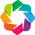

:Overlay
   .Scatter.I :Scatter   [actual_swe]   (pred_swe)
   .Curve.I   :Curve   [x]   (y)

In [91]:

hv.extension('bokeh')

# 1. Generate the scatter plot of all test points
scatter_plot = diagnostics_test.hvplot.scatter(
    x='actual_swe',
    y='pred_swe',
    alpha=0.2,
    color='teal',
    xlabel='Observed SNOTEL SWE (mm)',
    ylabel='Predicted RF SWE (mm)',
    title='Missouri Headwaters: Observed vs. Predicted SWE',
    frame_width=500,
    frame_height=500
)

# 2. Create a perfect 1:1 reference line
max_val = max(diagnostics_test['actual_swe'].max(), diagnostics_test['pred_swe'].max())

one_to_one_line = hv.Curve(([0, max_val], [0, max_val])).opts(
    color='red', 
    line_dash='dashed', 
    line_width=2
)

# Overlay them
observed_vs_predicted = scatter_plot * one_to_one_line
observed_vs_predicted

In [ ]:
# add date to diagnostics df
diagnostics_test['date'] = stations_test['date']
diagnostics_test = diagnostics_test.set_index('date')

# aggregate by date to see the watershed's seasonal trajectory
temporal_profile = diagnostics_test.groupby(diagnostics_test.index).mean()

# make a yearly plot to show testing performance
hydrograph = temporal_profile.hvplot.line(
    y=['actual_swe', 'pred_swe'],
    value_label='SWE (mm)',
    legend='top_left',
    color=['black', 'blue'],
    line_width=[2, 2],
    title='Watershed-Average SWE Hydrograph (Holdout Period)',
    frame_width=800,
    frame_height=400
)

# save the hydrograph
hydro_path = Path(output_dir, 'annual_hydrograph_plot.html')
hvplot.save(hydrograph, hydro_path)

# show the plot
hydrograph

:NdOverlay   [Variable]
   :Curve   [date]   (SWE (mm))

## Step 5: Hyperparameter Tuning

##### Round 1 of Hyperparameter Tuning

This round was completed before the addition of two more features to the dataset, so it's a decent place to start from, but more tuning is needed.

In [ ]:
# # reset model
# rf_model = RandomForestRegressor(random_state=42)

# # define a parameter distribution
# params = {
#     # set the number of possible trees
#     'n_estimators': [100, 200, 300, 400, 500],
#     # how many features each tree can consider
#     'max_features': ['sqrt', 'log2'],
#     # how deep each tree can go
#     'max_depth': [10, 20, 30, 40, 50],
# }

# # use a time series cross validation
# # otherwise, RandomizedSearch will use a cross validation that is incompatible with climate data
# tscv = TimeSeriesSplit(n_splits=5)

# # set up a randomized search
# rf_random = RandomizedSearchCV(
#     # use the rf model
#     estimator = rf_model,
#     # search through the dictionary
#     param_distributions = params,
#     # number of param iterations to try
#     n_iter = 25,
#     # use the time series cross validation
#     cv = tscv,
#     # optimize for RMSE error, as that was worse than R2
#     scoring='neg_root_mean_squared_error',
#     # enable parallelization
#     n_jobs = -1
# )

# # complete the randomized search
# rf_random.fit(x_train, y_train)

# # extract best parameters
# print("First round of hyperparameter tuning results:", rf_random.best_params_)
# r1_best_params = rf_random.best_estimator_
# r1_best_params

c:\Users\raini\miniconda3\envs\earth-analytics-python\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


First round of hyperparameter tuning results: {'n_estimators': 500, 'max_features': 'log2', 'max_depth': 30}


,n_estimators,500
,criterion,'squared_error'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##### Round 2 of Hyperparameter Tuning

This round will narrow the search, guided by the first round but not fully believing it. The first round of hyperparameter tuning results were: {'n_estimators': 500, 'max_features': 'log2', 'max_depth': 30}

Following this, the second round will use n_features: [400, 500, 600], the same max features, and max_depth: [20, 30, 40]

In [ ]:
# # set new params
# params = {
#     'n_estimators': [400, 500, 600],
#     'max_features': ['sqrt', 'log2'],
#     'max_depth': [20, 30, 40],
# }

# # set up the randomized search
# rf_random_2 = RandomizedSearchCV(
#     # use the rf model
#     estimator = rf_model,
#     # search through the dictionary
#     param_distributions = params,
#     # number of param iterations to try
#     n_iter = 18,
#     # use the time series cross validation
#     cv = tscv,
#     # optimize for RMSE error, as that was worse than R2
#     scoring='neg_root_mean_squared_error',
#     # enable parallelization
#     n_jobs = -1
# )

# # complete the randomized search
# rf_random_2.fit(x_train, y_train)

c:\Users\raini\miniconda3\envs\earth-analytics-python\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [20, 30, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [400, 500, ...]}"
,n_iter,18
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [ ]:
# # extract best parameters
# print("Second round of hyperparameter tuning results:", rf_random_2.best_params_)
# r2_best_params = rf_random_2.best_estimator_
# r2_best_params

Seond round of hyperparameter tuning results: {'n_estimators': 400, 'max_features': 'sqrt', 'max_depth': 40}


,n_estimators,400
,criterion,'squared_error'
,max_depth,40
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


These results are a bit interesting. The max_features changed from log2 to sqrt, indicating that the model is benefiting from the additional features added. Further, the n_estimators actually went down to 400 from 500. Finally, the max_depth went up to 40, indicating that the model is benefiting from the additional features and building additional complexity.

##### Round 3 of Hyperparameter Tuning

Scores from the second round of tuning aren't markedly better than before. This round will keep the n_estimators and the max_depth, but try a Grid Search with a greater number of features.

In [ ]:
# # reset model
# rf_grid = RandomForestRegressor(random_state=42, n_jobs=-1)

# # set up params again
# params_grid = {
#     'n_estimators': [400],
#     'max_depth': [40],
#     # with 15 features, 'sqrt' will include 3 features (20%) of the features from the dataset in each tree
#     # this search will test how including half and three quarters of the features performs
#     'max_features': ['sqrt', 0.5, 0.75]
# }

# # set up Grid Search
# grid_search = GridSearchCV(
#     estimator=rf_grid,
#     param_grid=params_grid,
#     cv=tscv,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# # perform grid search
# grid_search.fit(x_train, y_train)

# # Print results
# print("Best Parameters from Grid Search:", grid_search.best_params_)
# gs_best_params = grid_search.best_estimator_
# gs_best_params

Fitting 5 folds for each of 3 candidates, totalling 15 fits


c:\Users\raini\miniconda3\envs\earth-analytics-python\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best Parameters from Grid Search: {'max_depth': 40, 'max_features': 'sqrt', 'n_estimators': 400}


,n_estimators,400
,criterion,'squared_error'
,max_depth,40
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


These results confirm that the previous set of parameters were the best - max_features is still best left as sqrt.

## Step 6: Run RF Model with final parameters

In [10]:
# run model with updated parameters

rf_final = RandomForestRegressor(
    n_estimators=400,
    max_features='sqrt',
    max_depth=40,
    random_state=42,
    n_jobs=2
)

In [11]:
# fit model
rf_final.fit(x_train, y_train)

# predict
rf_preds_final = rf_final.predict(x_test)

c:\Users\raini\miniconda3\envs\earth-analytics-python\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


## Step 7: Model Validation

In [12]:
# Evaluate model performance

# Calculate some error statistics
rf_rmse_final = root_mean_squared_error(y_test, rf_preds_final)
rf_r2_final = r2_score(y_test, rf_preds_final)

# check error statistics
print(f"RF Test RMSE: {rf_rmse_final} mm")
print(f"RF Test R^2: {rf_r2_final}")

RF Test RMSE: 116.29735179929513 mm
RF Test R^2: 0.7354815274662116


Hyperparameter tuning and additional feature engineering clearly improve model performance. With the addition of Day of Water Year (DOWY) and shifting from 3-day to 7-day rolling windows, RMSE dropped, while R^2 remained roughly the same or improved. Hyperparameter tuning had similar effects. This finding is in alignment with Alabi et al. 2026, who found that DOWY was a crucial component of model accuracy, as well as the increased performance of 7-day rolling windows.

In [13]:
# Create a quick diagnostic dataframe for the test set
# (Assuming x_test has your date index or a 'water_year' column)
model_val_df = stations_test.copy()
model_val_df = model_val_df.rename(columns={'swe_mm': 'obs_swe'})
model_val_df['pred_swe'] = rf_preds_final

#### Step 7a: Scatter Plot

In [14]:

# hv.extension('bokeh')

# 1. Generate the scatter plot of all test points
scatter_plot = model_val_df.hvplot.scatter(
    x='obs_swe',
    y='pred_swe',
    alpha=0.2,
    color='teal',
    xlabel='Observed SNOTEL SWE (mm)',
    ylabel='Predicted RF SWE (mm)',
    title='Missouri Headwaters: Observed vs. Predicted SWE',
    frame_width=500,
    frame_height=500
)

# 2. Create a perfect 1:1 reference line
max_val = max(model_val_df['obs_swe'].max(), model_val_df['pred_swe'].max())

one_to_one_line = hv.Curve(([0, max_val], [0, max_val])).opts(
    color='red', 
    line_dash='dashed', 
    line_width=2
)

# Overlay them
observed_vs_predicted = scatter_plot * one_to_one_line
observed_vs_predicted

:Overlay
   .Scatter.I :Scatter   [obs_swe]   (pred_swe)
   .Curve.I   :Curve   [x]   (y)

#### Step 7b: Hydrograph

In [15]:
# add date to validation df
model_val_df = model_val_df.set_index('date')

In [16]:
# aggregate by date to see the watershed's seasonal trajectory
temp_profile_df = model_val_df.groupby(model_val_df.index).mean(numeric_only=True)
temp_profile_df = temp_profile_df.rename(columns = {'obs_swe': 'Observed SWE', 
                                   'pred_swe': 'Predicted SWE'})

# make a yearly plot to show testing performance
hydrograph = temp_profile_df.hvplot.line(
    y=['Observed SWE', 'Predicted SWE'],
    #label = ['Observed SWE', 'Predicted SWE'],
    value_label='SWE (mm)',
    xlabel = 'Year',
    legend='top_left',
    color=['black', 'blue'],
    line_width=[2, 2],
    title='Missouri Headwaters: Average SWE Hydrograph (Testing Period)',
    frame_width=800,
    frame_height=400
)

# save the hydrograph
output_dir = Path(proj_dir, 'outputs')
hydro_path = Path(output_dir, 'annual_hydrograph_plot.html')
#hvplot.save(hydrograph, hydro_path)

# show the plot
hydrograph

:NdOverlay   [Variable]
   :Curve   [date]   (SWE (mm))

#### Step 7c: Get Mean Bias Error at Each Station

In [17]:
# import study area gdf
mhw_bound_path = Path(cleaned_data_dir, 'boundaries', 'mhw_buff_clip_gdf.parquet')
mhw_gdf = gpd.read_parquet(mhw_bound_path)

mhw_gdf

,geometry
1,"POLYGON ((-112.30924 46.46774, -112.30363 46.4..."


In [18]:
# get mean bias error per station

# get raw error
model_val_df['error'] = model_val_df['obs_swe'] - model_val_df['pred_swe']

# get mean error per station
station_error_df = model_val_df.groupby('stationTriplet').agg(
    # get station elevation, lat, and lon ('first' aggregation as this value is static)
    elevation = ('elevation', 'first'),
    lat = ('latitude', 'first'), 
    lon = ('longitude', 'first'),
    # take the mean of each station's error
    mean_bias_error = ('error', 'mean'),
    # calculate root mean squared error
    rmse = ('error', lambda x: np.sqrt((x**2).mean()))
).reset_index()

# check to ensure the right number of stations were counted (should be 25)
print(f"Number of stations calculated: {len(station_error_df)}")

Number of stations calculated: 25


In [19]:
# calculate mean bias error over the whole basin
mean_bias = (station_error_df['mean_bias_error'].sum() / len(station_error_df['mean_bias_error']))
print(f'MBE: {mean_bias}')

# calculate average station bias
avg_bias = model_val_df['error'].mean()
print(f'Average Bias: {avg_bias}')


MBE: 2.0715987070846715
Average Bias: 2.0715987070846698


In [20]:
# make a plot of MBE vs elevation
station_scatter = station_error_df.hvplot.scatter(
    x ='elevation',
    y = 'mean_bias_error',
    c = 'mean_bias_error',
    cmap = 'RdBu_r',
    xlabel = 'Elevation (m)',
    ylabel = 'Mean Bias Error (mm)',
    title = 'Missouri Headwaters: Station Mean Bias Error vs Elevation',
    hover_cols = ['stationTriplet', 'rmse']
)

# make a zero line
zero_line = hv.HLine(0).opts(color = 'black', line_dash = 'dashed')

# overlay the two
station_scatter_zl = station_scatter * zero_line

# save the plot
scatter_path = Path(output_dir, 'station_scatter.html')
hvplot.save(station_scatter_zl, scatter_path)

# show the plot
station_scatter_zl

:Overlay
   .Scatter.I :Scatter   [elevation]   (mean_bias_error,stationTriplet,rmse)
   .HLine.I   :HLine   [x,y]

Mean Bias Error doesn't necessarily seem to be correlated to elevation - while one of the greatest positive outliers is at high elevation, the highest elevation station has very little MBE, and there's other stations near the elevation of the outlier with very little error. The other outliers (positive and negative) seem to be in the middle of the elevation range.

#### Step 7d: Make a Geographic Error Plot

In [21]:
# make a geographic plot

station_spatial = station_error_df.hvplot.points(
    x = 'lon',
    y = 'lat',
    geo = True,
    tiles = 'EsriNatGeo',
    # color on MBE
    c = 'mean_bias_error',
    # scale marker on RMSE
    s = 'rmse',
    scale = 2,
    cmap = 'RdBu_r',
    hover_cols = ['stationTriplet', 'elevation', 
                  'mean_bias_error', 'rmse'],
    xlabel = 'Longitude',
    ylabel = 'Latitude',
    clabel = 'Error (mm)',
    title = 'Missouri Headwaters: Spatial Error Distribution (Color = MBE, Size = RMSE)',
    frame_width = 600,
    frame_height = 500
)

# make a boundary plot
mhw_bound_plot = mhw_gdf.hvplot(
    geo = True,
    line_color = 'Black',
    fill_color = None
)

# overlay the study boundary
station_spatial_bound = station_spatial * mhw_bound_plot

# save the plot
station_spatial_path = Path(output_dir, 'spatial_station_error.html')
hvplot.save(station_spatial_bound, station_spatial_path)

# show the plot
station_spatial_bound

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Points.I   :Points   [lon,lat]   (mean_bias_error,rmse,stationTriplet,elevation)
   .Polygons.I :Polygons   [Longitude,Latitude]

From a spatial perspective, the greatest positive error is found at station 436:MT:SNTL. This station is right on the continental divide, at the far western edge of the boundary. This station could be overestimating because of some phenomenon stemming from the Continental Divide, or there could potentially be an error with the station's record. The other two greatest positive errors are found in the Madison Range (590:MT:SNTL, 347:MT:SNTL).

The greatest negative errors are found at 813:MT:SNTL, in the Gravelly range, and 916:MT:SNTL, in the Tobacco Root range.

#### Step 7e: Make a Feature Importance Plot

In [22]:
# get importances
rf_importance = rf_final.feature_importances_
sorted_import = pd.Series(rf_importance, index = x_test.columns).sort_values(ascending=True)

In [23]:
# make a plot
import_plot = sorted_import.hvplot.bar(
    title = 'MHW: Random Forests Feature Importance',
    xlabel = 'Feature',
    ylabel = 'Importance',
    height = 500,
    width = 1000,
    # rotate the xlabels by 45 degrees
    rot = 45,
)

# save the plot
importance_plot_path = Path(output_dir, 'feature_importance_plot.html')
hvplot.save(import_plot, importance_plot_path)

# show the plot
import_plot

:Bars   [index]   (0)

## Step 8: Save ML model

In [24]:
# save model with pickle

# set path
ml_model_path = Path(ml_dir, 'trained_rf_model.pkl')

# save using path and pickle.dump
with open(ml_model_path, 'wb') as f:
    pickle.dump(
        # model
        rf_final, 
        # path
        f, 
        # optimize memory usage
        protocol=5)

## Step 9: Apply ML to PRISM dataset

In [25]:
# open PRISM df

# set path
prism_path = Path(ml_dir, 'prism_raster.parquet')

# stream w/ parquet
# this lets the computer only read the data it needs at a given instant
prism_pq = pq.ParquetFile(prism_path)

In [26]:
# predict SWE across prism_df in chunks

# initialize chunks
pred_chunks = []

# set coordinate columns
coords = ['date', 'latitude', 'longitude']

# calculate total batches
batch_size = 500_000
total_rows = prism_pq.metadata.num_rows
total_batches = math.ceil(total_rows / batch_size)

# loop through prism_df in chunks, fitting model
for i, batch in enumerate(prism_pq.iter_batches(batch_size=500_000)):

    # convert the chunk to a pandas df
    df_chunk = batch.to_pandas()

    # isolate chunk date and ML features
    chunk_coords = df_chunk[coords].copy()
    x_chunk = df_chunk.drop(columns='date')

    # predict SWE 
    chunk_coords['swe_pred'] = rf_final.predict(x_chunk)

    # append to list
    pred_chunks.append(chunk_coords)

    # Print an update
    print(f'Predicted batch {i+1} of {total_batches}.')

# recombine chunks
pred_df = pd.concat(pred_chunks, ignore_index=True)


Predicted batch 1 of 38.
Predicted batch 2 of 38.
Predicted batch 3 of 38.
Predicted batch 4 of 38.
Predicted batch 5 of 38.
Predicted batch 6 of 38.
Predicted batch 7 of 38.
Predicted batch 8 of 38.
Predicted batch 9 of 38.
Predicted batch 10 of 38.
Predicted batch 11 of 38.
Predicted batch 12 of 38.
Predicted batch 13 of 38.
Predicted batch 14 of 38.
Predicted batch 15 of 38.
Predicted batch 16 of 38.
Predicted batch 17 of 38.
Predicted batch 18 of 38.
Predicted batch 19 of 38.
Predicted batch 20 of 38.
Predicted batch 21 of 38.
Predicted batch 22 of 38.
Predicted batch 23 of 38.
Predicted batch 24 of 38.
Predicted batch 25 of 38.
Predicted batch 26 of 38.
Predicted batch 27 of 38.
Predicted batch 28 of 38.
Predicted batch 29 of 38.
Predicted batch 30 of 38.
Predicted batch 31 of 38.
Predicted batch 32 of 38.
Predicted batch 33 of 38.
Predicted batch 34 of 38.
Predicted batch 35 of 38.
Predicted batch 36 of 38.
Predicted batch 37 of 38.
Predicted batch 38 of 38.


In [28]:
# set a multi index
pred_df_multi = pred_df.set_index(['date', 'latitude', 'longitude'])

In [29]:
# convert back to Dataset
pred_ds = pred_df_multi.to_xarray()
# pred_ds.set_coords('date')
# pred_ds.set_coords('latitude')
# pred_ds.set_coords('longitude')

In [30]:
# check the ds
pred_ds

<xarray.Dataset> Size: 248MB
Dimensions:    (date: 7328, latitude: 51, longitude: 83)
Coordinates:
  * date       (date) datetime64[ns] 59kB 1990-10-01 1990-10-02 ... 2020-06-01
  * latitude   (latitude) float64 408B 44.38 44.42 44.46 ... 46.38 46.42 46.46
  * longitude  (longitude) float64 664B -113.9 -113.9 -113.8 ... -110.5 -110.5
Data variables:
    swe_pred   (date, latitude, longitude) float64 248MB nan nan nan ... nan nan

In [32]:
# save prism_ds
pred_ds_path = Path(ml_dir, 'predicted_swe_MHW.nc')
pred_ds.to_netcdf(pred_ds_path)

## Step 10: Visualize PRISM SWE data

In [33]:
# get water year dates again
water_year_values = pred_ds['date'].dt.year + (pred_ds['date'].dt.month >= 10).astype(int)
pred_ds = pred_ds.assign_coords(water_year = water_year_values)

#### Step 10a: Annual Max Basin Volume

In [34]:
# convert swe to km and multiply by grid cell size
pred_ds['pred_swe_km3'] = pred_ds['swe_pred'] * 1e-6 * 16

# get daily basin volume
daily_vol = pred_ds['pred_swe_km3'].sum(dim=['latitude', 'longitude'])

# get max SWE volume and date per water year
ann_peak_vol = (daily_vol.groupby('water_year').max(dim = 'date'))
peak_vol_date = daily_vol.groupby('water_year').map(lambda x: x.idxmax(dim = 'date'))

# combine into df
peak_swe_df = pd.DataFrame({
    'peak_swe_km3': ann_peak_vol.to_pandas(),
    'peak_date': peak_vol_date.to_pandas()
}).reset_index()

# compare day of year
peak_swe_df['doy'] = peak_swe_df['peak_date'].dt.day_of_year

peak_swe_df

,water_year,peak_swe_km3,peak_date,doy
0,1991,6.980589,1991-04-17,107
1,1992,6.147171,1992-04-24,115
2,1993,7.048781,1993-04-13,103
3,1994,6.111380,1994-04-09,99
4,1995,8.348049,1995-03-29,88
5,1996,7.971761,1996-03-30,90
6,1997,8.809670,1997-04-11,101
7,1998,7.099706,1998-04-18,108
8,1999,7.280069,1999-04-10,100
9,2000,6.159649,2000-04-03,94


In [35]:
# get trends for swe and doy
swe_slope, swe_intercept = np.polyfit(peak_swe_df['water_year'], peak_swe_df['peak_swe_km3'], 1)
doy_slope, doy_intercept = np.polyfit(peak_swe_df['water_year'], peak_swe_df['doy'], 1)
peak_swe_df['swe_trend'] = swe_slope * peak_swe_df['water_year'] + swe_intercept
peak_swe_df['doy_trend'] = doy_slope * peak_swe_df['water_year'] + doy_intercept


# make peak volume and timing plot
ann_vol_plot = peak_swe_df.hvplot.scatter(
    x = 'water_year',
    y = 'peak_swe_km3',
    c = 'doy',
    title = 'MHW: Annual Maximum Predicted Basin SWE Volume',
    xlabel = 'Water Year',
    ylabel = 'SWE Volume (km^3)',
    clabel = 'Day of Year',
    cmap = 'RdBu',
    hover_cols = ['peak_date', 'peak_swe_km3'],
    height = 500,
    width = 800
# put the colorbar on the bottom
)#.opts(colorbar_position='bottom')

# make a line plot
peak_swe_line = peak_swe_df.hvplot.line(
    x = 'water_year', y = 'peak_swe_km3', 
    color = 'grey', alpha = 0.2, hover=False)
    
# make a max SWE trendline
swe_trend = (peak_swe_df
             # temporarily assign trend values to data values so the trend line shares an axis
             .assign(peak_swe_km3 = peak_swe_df['swe_trend']).hvplot.line(
    x = 'water_year', y = 'peak_swe_km3',
    color = 'blue', line_dash = 'dashed', alpha = 0.4, hover = False))

# make doy trendline
doy_trend = peak_swe_df.hvplot.line(
    x = 'water_year',
    y = 'doy_trend',
    ylabel = 'Day of Year',
    color = 'red', line_dash = 'dashdot', alpha = .04, hover = False)

# overlay all of them
max_vol_plot = (ann_vol_plot * peak_swe_line * swe_trend)# * doy_trend).opts(multi_y = True)

# save plot
max_vol_path = Path(output_dir, 'max_vol_plot.html')
#hvplot.save(max_vol_plot, max_vol_path)

# show plot
max_vol_plot

:Overlay
   .Scatter.I :Scatter   [water_year]   (peak_swe_km3,doy,peak_date)
   .Curve.I   :Curve   [water_year]   (peak_swe_km3)
   .Curve.II  :Curve   [water_year]   (peak_swe_km3)

In [ ]:
# check how the doy is changing each year
doy_slope

np.float64(-0.6551724137930978)

There's a clear trend in earlier peak SWE dates as time goes on. After 2005, most peak SWE dates are in early March. This is significantly earlier than the typical April 1 expectation of peak SWE. Because the study area includes valley floors (like the Madison River valley or the Gallatin Valley), it's likely that these valleys driving the earlier peak SWE date.

However, there is a slight positive trend in max SWE volume over the period, which is interesting.

#### Step 10b: April 1 SWE from a Given Year

In [37]:
# set target date 
target_date = (pred_ds['date'].dt.month == 4) & (pred_ds['date'].dt.day == 1)
april_ds = pred_ds.sel(date=target_date)

# set spatial dims and CRS
april_ds = april_ds.rio.set_spatial_dims(x_dim = 'longitude', y_dim = 'latitude')
april_ds = april_ds.rio.write_crs('EPSG:4326')

# clip ds
april_clip_ds = april_ds.rio.clip(mhw_gdf.geometry, drop=True, all_touched=True)

In [38]:
# make basemaps
terrain = hv.element.tiles.EsriTerrain()
reference = hv.element.tiles.EsriReference()

# get max swe for all aprils
max_swe = float(april_clip_ds['swe_pred'].max())
quant_099_swe = float(april_clip_ds['swe_pred'].quantile(0.99))

print(f'Absolute Max SWE: {max_swe}')
print(f'99th Percentile SWE: {quant_099_swe}')

Absolute Max SWE: 1099.0523627551024
99th Percentile SWE: 439.5141047806336


In [39]:
# ensure panel is loaded
pn.extension()

# make a spatial plot of April 1, 2005 SWE
widget_swe_layer = april_clip_ds['swe_pred'].hvplot.image(
    geo = True,
    groupby = 'date', # this makes a plot for each year!
    cmap = 'Sunset_r',
    title = f'MHW: Predicted SWE on April 1',
    xlabel = 'Longitude',
    ylabel = 'Latitude',
    clim = (0, quant_099_swe),
    height = 600,
    width = 800,
    colorbar = True,
    clabel = 'SWE Depth (mm)',
    alpha = 0.7,
)

# overlay all three
april_swe_plot = terrain * widget_swe_layer * reference
april_swe_plot = pn.panel(april_swe_plot, widget_location = 'bottom')

# save plot
april_swe_path = Path(output_dir, 'april_spatial_swe_slider_plot.html')
hvplot.save(april_swe_plot, april_swe_path, embed=True)

# show plot
april_swe_plot

BokehModel(combine_events=True, render_bundle={'docs_json': {'5370f966-21fd-41db-a738-61cc0422d562': {'version…

#### Step 10c: SWE Development over the Year Animation

In [143]:
# get target year, set spatial dims and CRS for new ds, clip
winter_ds = pred_ds.where(pred_ds['water_year'] == 1997, drop = True)
winter_ds = winter_ds.rio.set_spatial_dims(x_dim = 'longitude', y_dim = 'latitude')
winter_ds = winter_ds.rio.write_crs('EPSG:4326')
winter_ds = winter_ds.rio.clip(mhw_gdf.geometry, drop = True, all_touched = True)

# get 99th percentile swe val
winter_quant_099_swe = float(winter_ds['swe_pred'].quantile(0.99))

# change date format for plotting
winter_ds['date'] = winter_ds['date'].dt.strftime('%b %d, %Y')

In [152]:
# load panel
pn.extension()

# make winter plot
anim_layer = winter_ds['swe_pred'].hvplot.image(
    geo = True,
    groupby = 'date',
    # widget_type = 'scrubber',
    cmap = 'Sunset_r',
    clim = (0, winter_quant_099_swe),
    colorbar = True,
    title = 'MHW: Winter 1997 SWE Accumulation and Melt - {dimensions}',
    xlabel = 'Longitude',
    ylabel = 'Latitude',
    clabel = 'SWE (mm)',
    height = 600,
    width = 800,
    alpha = 0.7,
)

# overlay terrain and ref layers
anim_plot = terrain * anim_layer * reference
anim_plot = pn.panel(anim_plot, widget_type = 'scrubber', widget_location = 'bottom')

# save the plot
swe_anim_path = Path(output_dir, 'winter_1997_swe_animation.html')
swe_anim_embed_path = Path(output_dir, 'winter_1997_swe_animation_embed.html')
anim_plot.save(swe_anim_path)
anim_plot.save(swe_anim_embed_path, embed = True)

# show the plot
anim_plot

BokehModel(combine_events=True, render_bundle={'docs_json': {'dc6eb40f-2f6a-440c-a3e4-817257568922': {'version…